# M1 Phase 2 – Synthetic Image Detector (ResNet18)

This notebook covers the following tasks:
1. **Load CIFAKE Dataset** with train/val/test split (from M2's metadata)
2. **Normalize & Preprocess** images
3. **Model Architecture**: Pretrained ResNet18 with fine-tuning
4. **Training**: First on a small subset, then full training
5. **Checkpointing**: Save model checkpoints after each epoch
6. **Evaluation**: Accuracy, Precision, Recall, F1-score on val/test sets

**Deliverables**:
- Trained model file (`.pt`)
- Training/validation metrics: Accuracy, Precision, Recall, F1-score

---
## 0. Install Dependencies

In [5]:
!pip install torch torchvision scikit-learn matplotlib pandas tqdm pillow

---
## 1. Imports & Configuration

In [6]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# ── Paths ──────────────────────────────────────────────────────────────
# Change BASE_DIR to match your local dataset location
BASE_DIR       = r'/Users/arulkevin/Desktop/psg_hackathon/data'
METADATA_PATH  = os.path.join(BASE_DIR, 'metadata.csv')        # full dataset
SAMPLE_META    = os.path.join(BASE_DIR, 'sample_metadata.csv') # small subset
MODEL_DIR      = os.path.join(BASE_DIR, 'models')
RESULTS_DIR    = os.path.join(BASE_DIR, 'results_metrics')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────
BATCH_SIZE     = 64
NUM_WORKERS    = 0
LEARNING_RATE  = 1e-4
NUM_EPOCHS_SUB = 5    # epochs for subset training
NUM_EPOCHS_FULL = 10  # epochs for full training
IMG_SIZE       = 32   # CIFAKE images are 32×32

# ── Device ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Model checkpoints → {MODEL_DIR}")
print(f"Metric results    → {RESULTS_DIR}")

Using device: cpu
Model checkpoints → /Users/arulkevin/Desktop/psg_hackathon/data/models
Metric results    → /Users/arulkevin/Desktop/psg_hackathon/data/results_metrics


---
## 2. Dataset & Data Loaders

We reuse the `CIFAKEDataset` class and transforms defined in **M2_Phase1.ipynb**.
- **Train transform**: Random flip, rotation, colour jitter + normalisation
- **Val/Test transform**: Only normalisation

Normalisation uses **CIFAR-10 statistics** (the base of CIFAKE).

In [7]:
# ── Dataset class (same as M2) ────────────────────────────────────────
class CIFAKEDataset(Dataset):
    """Reads images listed in the metadata CSV produced by M2."""

    def __init__(self, csv_file, root_dir, split='train', transform=None):
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df['split'] == split].reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx]['filepath'])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx]['label'])

        if self.transform:
            image = self.transform(image)

        return image, label


# ── Transforms ─────────────────────────────────────────────────────────
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD  = [0.2023, 0.1994, 0.2010]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD),
])

print("Dataset class and transforms defined.")

Dataset class and transforms defined.


In [8]:
def build_loaders(csv_path, batch_size=BATCH_SIZE):
    """Return train / val / test DataLoaders for the given metadata CSV."""
    train_ds = CIFAKEDataset(csv_path, BASE_DIR, split='train', transform=train_transform)
    val_ds   = CIFAKEDataset(csv_path, BASE_DIR, split='val',   transform=val_test_transform)
    test_ds  = CIFAKEDataset(csv_path, BASE_DIR, split='test',  transform=val_test_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    print(f"  Train : {len(train_ds):>6,} images  |  {len(train_loader)} batches")
    print(f"  Val   : {len(val_ds):>6,} images  |  {len(val_loader)} batches")
    print(f"  Test  : {len(test_ds):>6,} images  |  {len(test_loader)} batches")

    return train_loader, val_loader, test_loader

# Quick sanity check with sample subset
print("Sample subset loaders:")
sample_train, sample_val, sample_test = build_loaders(SAMPLE_META)

Sample subset loaders:
  Train :  1,000 images  |  16 batches
  Val   :  1,000 images  |  16 batches
  Test  :  1,000 images  |  16 batches


---
## 3. Model Architecture – ResNet18 (Pretrained)

We use **ResNet18** pretrained on ImageNet and replace the final FC layer for **binary classification** (REAL vs FAKE).

**Fine-tuning strategy**:
- Freeze all layers initially
- Replace `fc` with a new head
- After subset training, unfreeze all layers for full training at a lower LR

In [9]:
def build_resnet18(num_classes=2, freeze_backbone=True):
    """Build a ResNet18 model with a custom classification head."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Optionally freeze backbone layers
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final fully-connected layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes),
    )

    return model.to(device)


model = build_resnet18(num_classes=2, freeze_backbone=True)

# Verify trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:>,}")
print(f"Trainable parameters : {trainable:>,}")
print(f"Frozen parameters    : {total_params - trainable:>,}")

Total parameters     : 11,308,354
Trainable parameters : 131,842
Frozen parameters    : 11,176,512


---
## 4. Training & Evaluation Utilities

In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Train for one epoch. Returns average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc='  Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluate on a data loader. Returns loss, accuracy, all preds & labels."""
    model.eval()
    running_loss = 0.0
    all_preds  = []
    all_labels = []

    for images, labels in tqdm(loader, desc='  Evaluating', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    total = len(all_labels)
    epoch_loss = running_loss / total
    epoch_acc  = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

print("Training and evaluation utilities defined.")

Training and evaluation utilities defined.


In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, checkpoint_prefix='resnet18'):
    """
    Full training loop with:
    - Per-epoch logging
    - Validation evaluation
    - Best-model checkpointing
    """
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        start = time.time()
        print(f"\nEpoch {epoch}/{num_epochs}")
        print('-' * 40)

        # ── Train ──
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        # ── Validate ──
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # ── Scheduler step ──
        if scheduler is not None:
            scheduler.step(val_loss)

        elapsed = time.time() - start
        print(f"  Train Loss: {train_loss:.4f}  |  Train Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f}  |  Val   Acc: {val_acc:.4f}")
        print(f"  Time: {elapsed:.1f}s")

        # ── Checkpoint ──
        ckpt_path = os.path.join(MODEL_DIR, f'{checkpoint_prefix}_epoch{epoch}.pt')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, ckpt_path)
        print(f"  Checkpoint saved → {ckpt_path}")

        # ── Best model ──
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            best_path = os.path.join(MODEL_DIR, f'{checkpoint_prefix}_best.pt')
            torch.save(model.state_dict(), best_path)
            print(f"  ★ New best model (val_acc={val_acc:.4f}) → {best_path}")

    # Load best weights
    model.load_state_dict(best_model_wts)
    print(f"\n✅ Training complete. Best val accuracy: {best_val_acc:.4f}")
    return model, history

print("Training loop defined.")

Training loop defined.


---
## 5. Phase A – Train on Small Subset (Quick Sanity Check)

We first train on the **sample subset** (3 000 images) to ensure the pipeline works before committing to the full dataset.

In [12]:
# Build model (frozen backbone)
model = build_resnet18(num_classes=2, freeze_backbone=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print("=" * 60)
print("PHASE A: Training on SAMPLE SUBSET (frozen backbone)")
print("=" * 60)

# Build sample loaders
sample_train, sample_val, sample_test = build_loaders(SAMPLE_META)

model, subset_history = train_model(
    model, sample_train, sample_val, criterion, optimizer, scheduler,
    num_epochs=NUM_EPOCHS_SUB,
    checkpoint_prefix='resnet18_subset'
)

PHASE A: Training on SAMPLE SUBSET (frozen backbone)
  Train :  1,000 images  |  16 batches
  Val   :  1,000 images  |  16 batches
  Test  :  1,000 images  |  16 batches

Epoch 1/5
----------------------------------------


  Train Loss: 0.7031  |  Train Acc: 0.5270
  Val   Loss: 0.6738  |  Val   Acc: 0.6120
  Time: 21.7s
  Checkpoint saved → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_epoch1.pt
  ★ New best model (val_acc=0.6120) → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_best.pt

Epoch 2/5
----------------------------------------


  Train Loss: 0.6910  |  Train Acc: 0.5500
  Val   Loss: 0.6621  |  Val   Acc: 0.6330
  Time: 20.0s
  Checkpoint saved → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_epoch2.pt
  ★ New best model (val_acc=0.6330) → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_best.pt

Epoch 3/5
----------------------------------------


  Train Loss: 0.6571  |  Train Acc: 0.6080
  Val   Loss: 0.6479  |  Val   Acc: 0.6590
  Time: 18.7s
  Checkpoint saved → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_epoch3.pt
  ★ New best model (val_acc=0.6590) → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_best.pt

Epoch 4/5
----------------------------------------


  Train Loss: 0.6426  |  Train Acc: 0.6300
  Val   Loss: 0.6340  |  Val   Acc: 0.6710
  Time: 19.3s
  Checkpoint saved → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_epoch4.pt
  ★ New best model (val_acc=0.6710) → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_best.pt

Epoch 5/5
----------------------------------------


  Train Loss: 0.6447  |  Train Acc: 0.6380
  Val   Loss: 0.6244  |  Val   Acc: 0.6730
  Time: 18.6s
  Checkpoint saved → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_epoch5.pt
  ★ New best model (val_acc=0.6730) → /Users/arulkevin/Desktop/psg_hackathon/data/models/resnet18_subset_best.pt

✅ Training complete. Best val accuracy: 0.6730


In [13]:
# Quick evaluation on sample test set
_, test_acc, test_preds, test_labels = evaluate(model, sample_test, criterion)

print("\n── Sample Test Set Results ──")
print(f"Accuracy  : {accuracy_score(test_labels, test_preds):.4f}")
print(f"Precision : {precision_score(test_labels, test_preds, average='binary'):.4f}")
print(f"Recall    : {recall_score(test_labels, test_preds, average='binary'):.4f}")
print(f"F1-Score  : {f1_score(test_labels, test_preds, average='binary'):.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['REAL', 'FAKE']))
print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, test_preds))


── Sample Test Set Results ──
Accuracy  : 0.6710
Precision : 0.6580
Recall    : 0.7120
F1-Score  : 0.6840

Classification Report:
              precision    recall  f1-score   support

        REAL       0.69      0.63      0.66       500
        FAKE       0.66      0.71      0.68       500

    accuracy                           0.67      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.67      0.67      0.67      1000


Confusion Matrix:
[[315 185]
 [144 356]]


---
## 8. Training Curves (Loss & Accuracy)

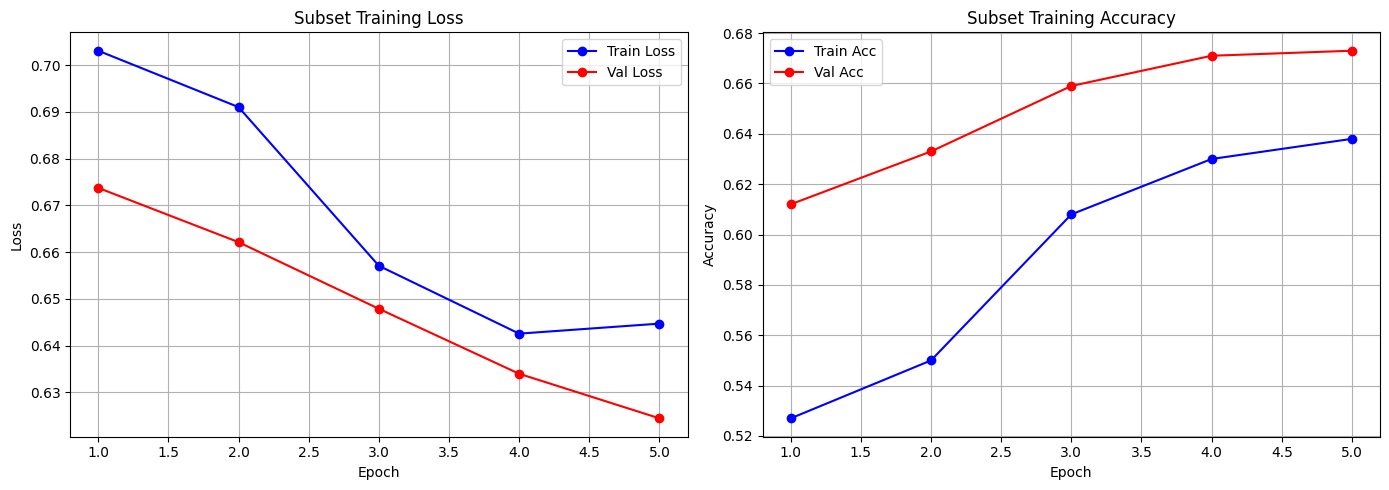

Plot saved to /Users/arulkevin/Desktop/psg_hackathon/data/results_metrics


In [15]:
def plot_history(history, title_prefix=''):
    """Plot training/validation loss and accuracy curves."""
    epochs_range = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
    axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss')
    axes[0].set_title(f'{title_prefix} Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
    axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc')
    axes[1].set_title(f'{title_prefix} Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'{title_prefix.lower().replace(" ", "_")}_curves.png'), dpi=150)
    plt.show()
    print(f"Plot saved to {RESULTS_DIR}")

# Plot subset training curves
plot_history(subset_history, title_prefix='Subset Training')


---
## 9. Confusion Matrix Visualization

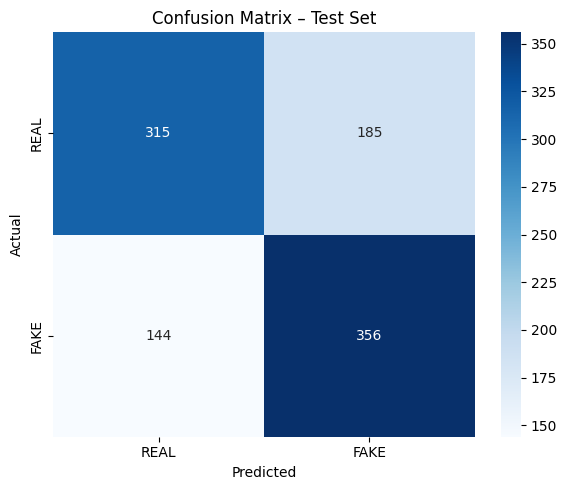

Confusion matrix saved → /Users/arulkevin/Desktop/psg_hackathon/data/results_metrics/confusion_matrix.png


In [16]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Test Set')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print(f"Confusion matrix saved → {RESULTS_DIR}/confusion_matrix.png")

---
## 10. Export Final Model

Save the final best model as a standalone `.pt` file for use by M3 (explainability).

In [17]:
final_model_path = os.path.join(MODEL_DIR, 'cifake_resnet18_final.pt')
torch.save(model.state_dict(), final_model_path)
print(f"\n✅ Final model exported → {final_model_path}")
print(f"   Model size: {os.path.getsize(final_model_path) / 1e6:.1f} MB")


✅ Final model exported → /Users/arulkevin/Desktop/psg_hackathon/data/models/cifake_resnet18_final.pt
   Model size: 45.3 MB


---
## Summary

| Deliverable | Location |
|---|---|
| Trained model (`.pt`) | `models/cifake_resnet18_final.pt` |
| Per-epoch checkpoints | `models/resnet18_*_epoch*.pt` |
| Test metrics CSV | `results_metrics/test_metrics.csv` |
| Training curves plot | `results_metrics/*_curves.png` |
| Confusion matrix plot | `results_metrics/confusion_matrix.png` |